# Estimate Demand System — Tanzania (Hicks)

## EEP 153 — Project 3

**Deliverable:** Counterfactual Experiments

**Data Source:** [Tanzania - Hicks Google Sheet](https://docs.google.com/spreadsheets/d/1LRe2bjhimuwrTXU8MpmQFH02MJegNRpmwNkY9T3HGqA/edit)

**Survey Waves:** 2019-20 and 2020-21

---

In [17]:
#Importing
import pandas as pd
import numpy as np
from datascience import *
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')
%matplotlib inline

In [25]:
#Reading files
FCT = pd.read_csv('Tanzania - Hicks - FCT.csv')
Household_characteristics = pd.read_csv('Tanzania - Household Characteristics.csv')
Nutrient_requirement = pd.read_csv('Tanzania - Hicks - RDA.csv')

#Reading files for 2019 - 2020
Food_Expenditure_1920_perday = pd.read_csv('Tanzania - Food Expenditures (2019-20).csv')
Food_Expenditure_1920_perday["Expenditure"] = Food_Expenditure_1920_perday["Expenditure"] / 30
Food_Prices_1920 = pd.read_csv('Tanzania - Food Prices (2019-20).csv').dropna(how='any')
Household_characteristics_1920 = Household_characteristics[Household_characteristics['t'] == "2019-20"]

#Reading files for 2020 - 2021
Food_Expenditure_2021_perday = pd.read_csv('Tanzania - Food Expenditures (2020-21).csv')
Food_Expenditure_2021_perday["Expenditure"] = Food_Expenditure_2021_perday["Expenditure"] / 30
Food_Prices_2021 = pd.read_csv('Tanzania - Food Prices (2020-21).csv').dropna(how='any')
Household_characteristics_2021 = Household_characteristics[Household_characteristics['t'] == "2020-21"]

#Mutiplying the expenditure
def change_price(df_expenditure, multiple):
    df_expenditure = df_expenditure.copy()
    df_expenditure["Expenditure"] = df_expenditure["Expenditure"] * multiple
    return df_expenditure



#Total nutrient for each household
def ttl_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price):
    
    #Merging datasets
    merged_df = pd.merge(Household_Characteristic, Expenditure.drop(columns=['t', 'm']), on='i', how='inner')
    merged_df = pd.merge(merged_df, Food_Price, on=["j","m"],how = "left")
    merged_df["Quantity of Food"] = merged_df["Expenditure"] / merged_df["Price"]
    merged_df = merged_df.drop_duplicates(subset=['i', 'j'], keep='first')
    merged_df = merged_df[["i", "m","log HSize", "j","u","Quantity of Food"]]
    merged_df = pd.merge(merged_df, FCT, on='j', how='left')
    
    df_total_nutrients_per_household = merged_df[[
        "i",
        "Quantity of Food",
        "Energy",
        "Protein",
        "Vitamin A",
        "Vitamin D",
        "Vitamin E",
        "Vitamin C",
        "Vitamin B-6",
        "Vitamin B-12",
        "Calcium",
        "Magnesium",
        "Iron",
        "Zinc",
        "Fiber"
    ]]
    
    nutrient_cols = [
        "Energy", "Protein", "Vitamin A", "Vitamin D", "Vitamin E",
        "Vitamin C", "Vitamin B-6", "Vitamin B-12",
        "Calcium", "Magnesium", "Iron", "Zinc", "Fiber"
    ]
    
    #Multiplying nutrients by quantity
    df_total_nutrients_per_household [nutrient_cols] = df_total_nutrients_per_household [nutrient_cols].multiply(df_total_nutrients_per_household ["Quantity of Food"], axis=0)
    
    #Grouping individuals
    df_total_nutrients_per_household = df_total_nutrients_per_household.groupby("i")[nutrient_cols].sum().reset_index()[["i"]+nutrient_cols]
    
    return df_total_nutrients_per_household




#Average nutrient for each person in the household
def avg_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price):
    ttl = ttl_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price)
    ttl_w_household = pd.merge(ttl, Household_Characteristic[["i","log HSize"]], on=["i"], how="left")

    #Create HSize from log HSize
    ttl_w_household["HSize"] = np.exp(
        ttl_w_household["log HSize"]
    )

    #Drop the old column
    ttl_w_household = ttl_w_household.drop(
        columns=["log HSize"]
    )

    nutrient_cols = [
    "Energy", "Protein", "Vitamin A", "Vitamin D", "Vitamin E",
    "Vitamin C", "Vitamin B-6", "Vitamin B-12",
    "Calcium", "Magnesium", "Iron", "Zinc", "Fiber"
    ]

    # divide each nutrient by household size
    ttl_w_household.loc[:, nutrient_cols] = (
        ttl_w_household[nutrient_cols]
        .div(ttl_w_household["HSize"], axis=0)
    )

    return ttl_w_household



#Calculate the total people who meet the nutrition requirement
def num_meet_requirement(FCT, Household_Characteristic, Expenditure, Food_Price, Requirement):
    ttl = ttl_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price)
    avg = avg_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price)
    merged_df = pd.merge(avg, Household_Characteristic, on=["i"], how="left")

    nutrient_cols = [
        "Energy", "Protein", "Vitamin A", "Vitamin D", "Vitamin E",
        "Vitamin C", "Vitamin B-6", "Vitamin B-12",
        "Calcium", "Magnesium", "Iron", "Zinc", "Fiber"
    ]

    demo_cols = [
    "Females 09-13", "Males 14-18", "Females 14-18",
    "Males 19-30", "Females 19-30",
    "Males 31-50", "Females 31-50",
    "Males 51-99", "Females 51-99"
    ]

    def expand_household(row):
        people = []
        for col in demo_cols:
            count = int(row[col])
            people.extend([col] * count)
        return people

    # Add new column to dataframe
    merged_df["household_list"] = merged_df.apply(expand_household, axis=1)

    meet_requirement = []
    
    for i in range(len(merged_df)):
        count = 0
        meet = True
        household_lst = merged_df.iloc[i][-1]
        for j in household_lst:
            for k in range(len(Nutrient_requirement[j])):
                if Nutrient_requirement[j][k] < merged_df.iloc[i][1+k]:
                    continue
                else:
                    meet = False
                    break
            if meet:
                count += 1
        meet_requirement.append(count)

    merged_df["meet_requirement"] = meet_requirement

    #Create HSize from log HSize
    merged_df["HSize"] = np.exp(
        merged_df["log HSize"]
    )

    #Drop the old column
    merged_df = merged_df.drop(
        columns=["log HSize"]
    )
        
    return merged_df



original_1920 = num_meet_requirement(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920, Nutrient_requirement)[['i', 'meet_requirement', "HSize"]]
original_1920

,i,meet_requirement,HSize
0,0001-001-001,0,2.0
1,0001-001-003,0,1.0
2,0001-001-004,0,1.0
3,0001-004-001,0,3.0
4,0001-004-002,0,1.0
...,...,...,...
1105,0856-001-001,0,11.0
1106,0856-001-003,0,7.0
1107,0857-001-001,0,8.0
1108,0858-001-001,0,3.0


In [3]:
avg_nutrient_household(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920)

,i,Energy,Protein,Vitamin A,Vitamin D,Vitamin E,Vitamin C,Vitamin B-6,Vitamin B-12,Calcium,Magnesium,Iron,Zinc,Fiber,HSize
0,0001-001-001,518.403637,14.728182,378.096444,0.000000,0.558643,11.797849,0.391289,0.045816,373.174324,79.395293,4.928986,2.085142,16.755339,2.0
1,0001-001-003,909.286460,24.596105,672.084749,0.525002,1.304771,21.137539,0.750967,0.459935,486.829630,173.679192,9.440993,4.364633,23.808637,1.0
2,0001-001-004,1091.409211,31.139540,781.871890,3.365833,2.573921,46.984595,0.980690,1.069261,122.577787,237.957683,7.815999,4.981592,11.693104,1.0
3,0001-004-001,584.991305,13.283734,479.968378,0.252779,1.631758,7.357942,0.317830,0.241251,233.831114,78.351056,3.322087,1.686134,9.964877,3.0
4,0001-004-002,509.620763,9.636940,194.990021,0.110772,0.325313,2.773496,0.315806,0.000000,384.721206,55.221991,4.294988,1.727958,17.836484,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1105,0856-001-001,125.569926,1.826373,55.787948,0.576318,0.078686,1.456853,0.022463,0.052829,25.271904,7.826015,0.224244,0.155635,2.825433,11.0
1106,0856-001-003,227.554127,5.308979,3.320279,0.905642,0.178512,1.587450,0.095434,0.083017,14.453271,25.947862,0.551035,0.508962,1.944671,7.0
1107,0857-001-001,261.516741,6.584286,18.454657,1.188655,0.478141,3.783434,0.148760,0.149031,56.176505,33.809027,0.994331,0.684258,4.507479,8.0
1108,0858-001-001,418.645988,11.510201,368.895051,0.701215,1.190587,5.009939,0.350585,0.064278,75.958682,146.249731,4.731073,2.165970,7.577491,3.0


In [4]:
ttl_nutrient_household(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920)

,i,Energy,Protein,Vitamin A,Vitamin D,Vitamin E,Vitamin C,Vitamin B-6,Vitamin B-12,Calcium,Magnesium,Iron,Zinc,Fiber
0,0001-001-001,1036.807274,29.456364,756.192889,0.000000,1.117285,23.595698,0.782578,0.091632,746.348648,158.790587,9.857971,4.170283,33.510677
1,0001-001-003,909.286460,24.596105,672.084749,0.525002,1.304771,21.137539,0.750967,0.459935,486.829630,173.679192,9.440993,4.364633,23.808637
2,0001-001-004,1091.409211,31.139540,781.871890,3.365833,2.573921,46.984595,0.980690,1.069261,122.577787,237.957683,7.815999,4.981592,11.693104
3,0001-004-001,1754.973914,39.851203,1439.905134,0.758337,4.895274,22.073827,0.953490,0.723752,701.493343,235.053169,9.966261,5.058403,29.894631
4,0001-004-002,509.620763,9.636940,194.990021,0.110772,0.325313,2.773496,0.315806,0.000000,384.721206,55.221991,4.294988,1.727958,17.836484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1105,0856-001-001,1381.269191,20.090105,613.667433,6.339495,0.865551,16.025382,0.247093,0.581120,277.990944,86.086166,2.466680,1.711984,31.079758
1106,0856-001-003,1592.878892,37.162850,23.241955,6.339495,1.249582,11.112151,0.668035,0.581120,101.172897,181.635035,3.857244,3.562731,13.612697
1107,0857-001-001,2092.133926,52.674288,147.637253,9.509242,3.825125,30.267473,1.190083,1.192250,449.412037,270.472217,7.954650,5.474066,36.059831
1108,0858-001-001,1255.937964,34.530602,1106.685152,2.103646,3.571761,15.029817,1.051756,0.192834,227.876047,438.749193,14.193218,6.497911,22.732474


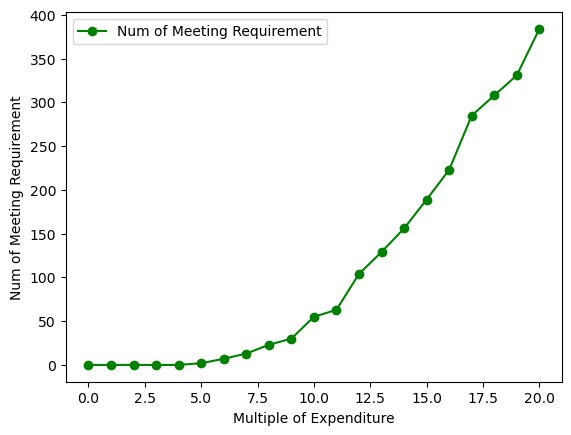

Total Number of People in the Dataset:  5434.0


In [23]:
def graph_meeting_nutrients(FCT, Household_Characteristic, Expenditure, Food_Price, Requirement):
    
    multiples_of_expenditures = list(range(21))
    ttl_meet_requirement = []
    for i in multiples_of_expenditures:
        current = num_meet_requirement(FCT, Household_Characteristic, change_price(Expenditure, i), Food_Price, Requirement)
        ttl_meet_requirement.append(sum(current['meet_requirement']))

    df = pd.DataFrame({
        "Multiple of Expenditure": multiples_of_expenditures,
        "Num of Meeting Requirement": ttl_meet_requirement
        })
        
    return df
    
graphing_1920 = graph_meeting_nutrients(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920, Nutrient_requirement)
graphing_1920.plot(x="Multiple of Expenditure", y="Num of Meeting Requirement", color="green", marker='o')
plt.xlabel("Multiple of Expenditure")
plt.ylabel("Num of Meeting Requirement")
plt.show()
print("Total Number of People in the Dataset: " , round(sum(avg_nutrient_household(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920)["HSize"]),0))

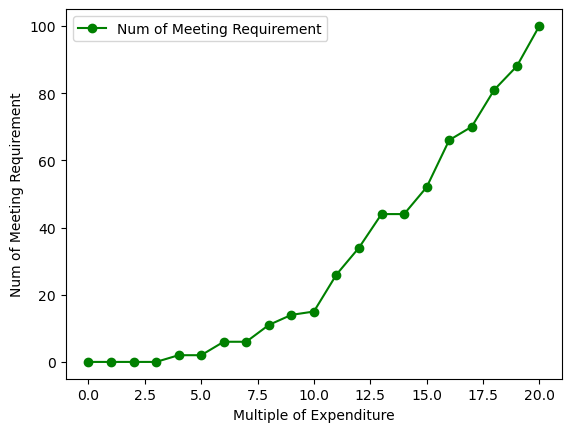

Total Number of People in the Dataset:  2198.0


In [26]:
graphing_2021 = graph_meeting_nutrients(FCT, Household_characteristics_2021, Food_Expenditure_2021_perday, Food_Prices_2021, Nutrient_requirement)
graphing_2021.plot(x="Multiple of Expenditure", y="Num of Meeting Requirement", color="green", marker='o')
plt.xlabel("Multiple of Expenditure")
plt.ylabel("Num of Meeting Requirement")
plt.show()
print("Total Number of People in the Dataset: " , round(sum(avg_nutrient_household(FCT, Household_characteristics_2021, Food_Expenditure_2021_perday, Food_Prices_2021)["HSize"]),0))